# 03 — Benchmark：多 Engine 效能比較

建立 FP32 / FP16 TRT engine，量測 trtexec 延遲與吞吐量，並與 ONNXRuntime GPU 基線比較。

| 步驟 | 內容 |
|------|------|
| 1 | 路徑設定 |
| 2 | ONNX 模型 shape 確認 |
| 3 | trtexec FP32 建引擎 + Benchmark |
| 4 | trtexec FP16 建引擎 + Benchmark |
| 5 | 解析 trtexec 指標 |
| 6 | ONNXRuntime GPU 基線（300 runs） |
| 6b | ORT TensorRT Execution Provider（選用）|
| 6c | ORT 延遲分布分析（直方圖 + Box Plot）|
| 7 | 彙總表格 + 4 圖（Mean、QPS、Tail Latency、Speedup）|

## 1. 路徑設定

In [1]:
from pathlib import Path
import os

TRTEXEC      = Path("C:/Users/edisonhsieh/Downloads/TensorRT-10.8.0.43.Windows.win10.cuda-12.8/TensorRT-10.8.0.43/bin/trtexec.exe")
ONNX_MODEL   = Path("C:/GPM_AI/H.onnx")
TEST_DATASET = Path("C:/Users/edisonhsieh/Downloads/Test_dataset")

ENGINES_DIR  = Path("engines")
ENGINES_DIR.mkdir(exist_ok=True)
ENGINE_FP32  = ENGINES_DIR / "H_fp32.engine"
ENGINE_FP16  = ENGINES_DIR / "H_fp16.engine"

WARMUP_MS = 1000   # trtexec warmup (ms)
DURATION_S = 15    # trtexec benchmark duration (s)
ORT_RUNS   = 300   # ONNXRuntime benchmark iterations

TRT_LIB = TRTEXEC.parent.parent / "lib"
if TRT_LIB.exists():
    os.environ["PATH"] = str(TRT_LIB) + os.pathsep + os.environ.get("PATH", "")
    print(f"TRT lib added to PATH : {TRT_LIB}")
else:
    print(f"WARNING: TRT lib not found at {TRT_LIB}")

print("Settings ready.")

TRT lib added to PATH : C:\Users\edisonhsieh\Downloads\TensorRT-10.8.0.43.Windows.win10.cuda-12.8\TensorRT-10.8.0.43\lib
Settings ready.


## 2. ONNX 模型 Shape 確認

In [2]:
import onnx

model = onnx.load(str(ONNX_MODEL))
onnx.checker.check_model(model)

def fmt_shape(tensor_type):
    dims = tensor_type.shape.dim
    return [d.dim_value if d.dim_value > 0 else (d.dim_param or "?") for d in dims]

print(f"Opset : {model.opset_import[0].version}")
for t in model.graph.input:
    print(f"Input : {t.name}  {fmt_shape(t.type.tensor_type)}")
for t in model.graph.output:
    print(f"Output: {t.name}  {fmt_shape(t.type.tensor_type)}")

_in    = model.graph.input[0]
_shape = fmt_shape(_in.type.tensor_type)
MODEL_H = _shape[2] if isinstance(_shape[2], int) else 448
MODEL_W = _shape[3] if isinstance(_shape[3], int) else 448
MODEL_C = _shape[1] if isinstance(_shape[1], int) else 3
print(f"\nInference shape: [1, {MODEL_C}, {MODEL_H}, {MODEL_W}]")

Opset : 12
Input : images  [1, 3, 448, 448]
Output: output  [1, 6]

Inference shape: [1, 3, 448, 448]


## 3. trtexec — FP32 引擎建立 + Benchmark
第一次執行會需要數分鐘（engine 建立）。若 engine 已存在會直接執行 benchmark。

In [3]:
import subprocess, time, re

def run_trtexec(onnx_path, engine_path, *, fp16=False,
                warmup_ms=WARMUP_MS, duration_s=DURATION_S):
    cmd = [
        str(TRTEXEC),
        f"--onnx={onnx_path}",
        f"--saveEngine={engine_path}",
        f"--warmUp={warmup_ms}",
        f"--duration={duration_s}",
    ]
    if fp16:
        cmd.append("--fp16")

    precision = "FP16" if fp16 else "FP32"
    print(f"[{precision}] Building engine → {engine_path}")
    print("CMD:", " ".join(cmd), "\n")

    t0   = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True)
    elapsed = time.time() - t0

    if proc.returncode != 0:
        print("=== STDERR ===")
        print(proc.stderr[-4000:])
    else:
        for line in proc.stdout.splitlines():
            if any(kw in line for kw in ["mean", "median", "percentile",
                                          "Throughput", "GPU Compute",
                                          "[I]", "[W]", "[E]"]):
                print(line)

    print(f"\nTotal elapsed: {elapsed:.1f}s")
    return proc, elapsed

proc_fp32, time_fp32 = run_trtexec(ONNX_MODEL, ENGINE_FP32, fp16=False)

[FP32] Building engine → engines\H_fp32.engine
CMD: C:\Users\edisonhsieh\Downloads\TensorRT-10.8.0.43.Windows.win10.cuda-12.8\TensorRT-10.8.0.43\bin\trtexec.exe --onnx=C:\GPM_AI\H.onnx --saveEngine=engines\H_fp32.engine --warmUp=1000 --duration=15 

[05/25/2026-17:05:30] [I] TF32 is enabled by default. Add --noTF32 flag to further improve accuracy with some performance cost.
[05/25/2026-17:05:30] [I] === Model Options ===
[05/25/2026-17:05:30] [I] Format: ONNX
[05/25/2026-17:05:30] [I] Model: C:\GPM_AI\H.onnx
[05/25/2026-17:05:30] [I] Output:
[05/25/2026-17:05:30] [I] === Build Options ===
[05/25/2026-17:05:30] [I] Memory Pools: workspace: default, dlaSRAM: default, dlaLocalDRAM: default, dlaGlobalDRAM: default, tacticSharedMem: default
[05/25/2026-17:05:30] [I] avgTiming: 8
[05/25/2026-17:05:30] [I] Precision: FP32
[05/25/2026-17:05:30] [I] LayerPrecisions: 
[05/25/2026-17:05:30] [I] Layer Device Types: 
[05/25/2026-17:05:30] [I] Calibration: 
[05/25/2026-17:05:30] [I] Refit: Disabled

## 4. trtexec — FP16 引擎建立 + Benchmark

In [4]:
proc_fp16, time_fp16 = run_trtexec(ONNX_MODEL, ENGINE_FP16, fp16=True)

[FP16] Building engine → engines\H_fp16.engine
CMD: C:\Users\edisonhsieh\Downloads\TensorRT-10.8.0.43.Windows.win10.cuda-12.8\TensorRT-10.8.0.43\bin\trtexec.exe --onnx=C:\GPM_AI\H.onnx --saveEngine=engines\H_fp16.engine --warmUp=1000 --duration=15 --fp16 

[05/25/2026-17:06:07] [I] === Model Options ===
[05/25/2026-17:06:07] [I] Format: ONNX
[05/25/2026-17:06:07] [I] Model: C:\GPM_AI\H.onnx
[05/25/2026-17:06:07] [I] Output:
[05/25/2026-17:06:07] [I] === Build Options ===
[05/25/2026-17:06:07] [I] Memory Pools: workspace: default, dlaSRAM: default, dlaLocalDRAM: default, dlaGlobalDRAM: default, tacticSharedMem: default
[05/25/2026-17:06:07] [I] avgTiming: 8
[05/25/2026-17:06:07] [I] Precision: FP32+FP16
[05/25/2026-17:06:07] [I] LayerPrecisions: 
[05/25/2026-17:06:07] [I] Layer Device Types: 
[05/25/2026-17:06:07] [I] Calibration: 
[05/25/2026-17:06:07] [I] Refit: Disabled
[05/25/2026-17:06:07] [I] Strip weights: Disabled
[05/25/2026-17:06:07] [I] Version Compatible: Disabled
[05/25/202

## 5. 解析 trtexec 輸出指標

In [5]:
def parse_trtexec(proc):
    text = proc.stdout
    m = {}
    patterns = {
        "mean_ms":        r"mean\s*=\s*([\d.]+)\s*ms",
        "median_ms":      r"median\s*=\s*([\d.]+)\s*ms",
        "p95_ms":         r"95th percentile.*?=\s*([\d.]+)\s*ms",
        "p99_ms":         r"99th percentile.*?=\s*([\d.]+)\s*ms",
        "throughput_qps": r"Throughput:\s*([\d.]+)\s*qps",
        "gpu_compute_ms": r"GPU Compute Time.*?mean\s*=\s*([\d.]+)\s*ms",
    }
    for key, pat in patterns.items():
        hit = re.search(pat, text, re.IGNORECASE)
        if hit:
            m[key] = float(hit.group(1))
    return m

m_fp32 = parse_trtexec(proc_fp32)
m_fp16 = parse_trtexec(proc_fp16)

print(f"{'Metric':<25} {'FP32':>10} {'FP16':>10}  Unit")
print("-" * 52)
for k in ["mean_ms", "median_ms", "p95_ms", "p99_ms", "gpu_compute_ms", "throughput_qps"]:
    v32  = m_fp32.get(k, float("nan"))
    v16  = m_fp16.get(k, float("nan"))
    unit = "QPS" if "qps" in k else "ms"
    print(f"{k:<25} {v32:>10.3f} {v16:>10.3f}  {unit}")

Metric                          FP32       FP16  Unit
----------------------------------------------------
mean_ms                        3.104      1.328  ms
median_ms                      3.049      1.330  ms
p95_ms                           nan        nan  ms
p99_ms                           nan        nan  ms
gpu_compute_ms                 2.993      1.219  ms
throughput_qps               310.942    692.363  QPS


## 6. ONNXRuntime GPU 基線
使用與 `onnx_inference.py` 相同的前處理（Resize + /255 + NCHW）量測延遲。

In [6]:
import onnxruntime as ort
import numpy as np
import time

session = ort.InferenceSession(
    str(ONNX_MODEL),
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)
inp_meta = session.get_inputs()[0]
inp_name = inp_meta.name
out_name = session.get_outputs()[0].name
active_provider = session.get_providers()[0]
print(f"Active provider : {active_provider}")
if active_provider == "CPUExecutionProvider":
    print("  ⚠  Fell back to CPU — check CUDA/TRT DLL PATH.")

dummy = np.random.rand(1, MODEL_C, MODEL_H, MODEL_W).astype(np.float32)

for _ in range(30):   # warmup
    session.run([out_name], {inp_name: dummy})

lat = np.empty(ORT_RUNS)
for i in range(ORT_RUNS):
    t0 = time.perf_counter()
    session.run([out_name], {inp_name: dummy})
    lat[i] = (time.perf_counter() - t0) * 1000

m_ort = {
    "mean_ms":        float(lat.mean()),
    "median_ms":      float(np.percentile(lat, 50)),
    "p95_ms":         float(np.percentile(lat, 95)),
    "p99_ms":         float(np.percentile(lat, 99)),
    "throughput_qps": float(1000 / lat.mean()),
}

label = active_provider.replace("ExecutionProvider", "")
print(f"\nONNXRuntime {label} — {ORT_RUNS} runs")
for k, v in m_ort.items():
    unit = "QPS" if "qps" in k else "ms"
    print(f"  {k:<20} {v:.3f} {unit}")

Active provider : CPUExecutionProvider
  ⚠  Fell back to CPU — check CUDA/TRT DLL PATH.

ONNXRuntime CPU — 300 runs
  mean_ms              43.195 ms
  median_ms            39.360 ms
  p95_ms               73.700 ms
  p99_ms               93.545 ms
  throughput_qps       23.151 QPS


## 6b. ONNXRuntime TensorRT Execution Provider
透過 ORT TensorRT EP 執行推論，比較與直接呼叫 trtexec / TRT Python API 的額外開銷。
若 `onnxruntime-gpu` 未安裝或 TRT EP 不可用，此 cell 會自動跳過。

In [7]:
m_ort_trt_ep = None

trt_ep_options = {
    "device_id": 0,
    "trt_engine_cache_enable": True,
    "trt_engine_cache_path": str(ENGINES_DIR),
    "trt_fp16_enable": False,
}

try:
    sess_trt_ep = ort.InferenceSession(
        str(ONNX_MODEL),
        providers=[
            ("TensorrtExecutionProvider", trt_ep_options),
            "CUDAExecutionProvider",
            "CPUExecutionProvider",
        ]
    )
    active_trt = sess_trt_ep.get_providers()[0]
    print(f"Active provider: {active_trt}")

    if "Tensorrt" not in active_trt:
        print("  ⚠  TensorRT EP not available — skipping.")
    else:
        for _ in range(30):
            sess_trt_ep.run([out_name], {inp_name: dummy})

        lat_ep = np.empty(ORT_RUNS)
        for i in range(ORT_RUNS):
            t0 = time.perf_counter()
            sess_trt_ep.run([out_name], {inp_name: dummy})
            lat_ep[i] = (time.perf_counter() - t0) * 1000

        m_ort_trt_ep = {
            "mean_ms":        float(lat_ep.mean()),
            "median_ms":      float(np.percentile(lat_ep, 50)),
            "p95_ms":         float(np.percentile(lat_ep, 95)),
            "p99_ms":         float(np.percentile(lat_ep, 99)),
            "throughput_qps": float(1000 / lat_ep.mean()),
        }
        print(f"\nORT TensorRT EP — {ORT_RUNS} runs")
        for k, v in m_ort_trt_ep.items():
            unit = "QPS" if "qps" in k else "ms"
            print(f"  {k:<20} {v:.3f} {unit}")

except Exception as e:
    print(f"TensorRT EP not available: {e}")

*************** EP Error ***************
EP Error E:\_work\1\s\onnxruntime\python\onnxruntime_pybind_state.cc:534 onnxruntime::python::RegisterTensorRTPluginsAsCustomOps Please install TensorRT libraries as mentioned in the GPU requirements page, make sure they're in the PATH or LD_LIBRARY_PATH, and that your GPU is supported.
 when using [('TensorrtExecutionProvider', {'device_id': 0, 'trt_engine_cache_enable': True, 'trt_engine_cache_path': 'engines', 'trt_fp16_enable': False}), 'CUDAExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
****************************************
Active provider: CPUExecutionProvider
  ⚠  TensorRT EP not available — skipping.


## 6c. ORT 延遲分布分析
直方圖 + Box Plot 展示推論延遲的分布與抖動（jitter），500 次取樣。

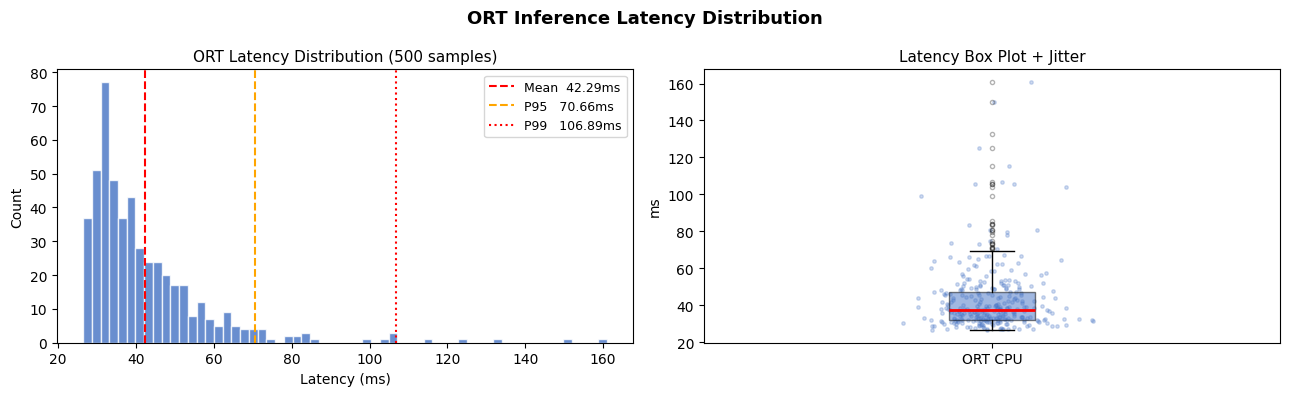

Saved → ort_latency_distribution.png


In [9]:
import matplotlib.pyplot as plt
 

LAT_SAMPLES = 500

lat_dist = np.empty(LAT_SAMPLES)
for i in range(LAT_SAMPLES):
    t0 = time.perf_counter()
    session.run([out_name], {inp_name: dummy})
    lat_dist[i] = (time.perf_counter() - t0) * 1000

mean_v = lat_dist.mean()
p95_v  = np.percentile(lat_dist, 95)
p99_v  = np.percentile(lat_dist, 99)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(lat_dist, bins=60, color="#4472C4", alpha=0.8, edgecolor="white")
axes[0].axvline(mean_v, color="red",    linestyle="--", linewidth=1.5, label=f"Mean  {mean_v:.2f}ms")
axes[0].axvline(p95_v,  color="orange", linestyle="--", linewidth=1.5, label=f"P95   {p95_v:.2f}ms")
axes[0].axvline(p99_v,  color="red",    linestyle=":",  linewidth=1.5, label=f"P99   {p99_v:.2f}ms")
axes[0].set_title(f"ORT Latency Distribution ({LAT_SAMPLES} samples)", fontsize=11)
axes[0].set_xlabel("Latency (ms)")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=9)

rng = np.random.default_rng(42)
axes[1].boxplot(lat_dist, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#4472C4", alpha=0.5),
                medianprops=dict(color="red", linewidth=2),
                flierprops=dict(marker=".", alpha=0.3))
jitter = rng.normal(1, 0.06, size=min(300, LAT_SAMPLES))
axes[1].scatter(jitter, lat_dist[:len(jitter)], alpha=0.25, s=6, color="#4472C4")
axes[1].set_title("Latency Box Plot + Jitter", fontsize=11)
axes[1].set_ylabel("ms")
axes[1].set_xticks([1])
axes[1].set_xticklabels([f"ORT {active_provider.replace('ExecutionProvider', '')}"])

plt.suptitle("ORT Inference Latency Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("ort_latency_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ort_latency_distribution.png")

## 7. 彙總表格 + 圖表

       Method  Mean (ms)  Median (ms)  P95 (ms)  P99 (ms)  Throughput (QPS)  Speedup
      ORT CPU     43.195       39.360    73.700    93.545            23.151    1.000
TensorRT FP32      3.104        3.049       NaN       NaN           310.942   13.914
TensorRT FP16      1.328        1.330       NaN       NaN           692.363   32.527


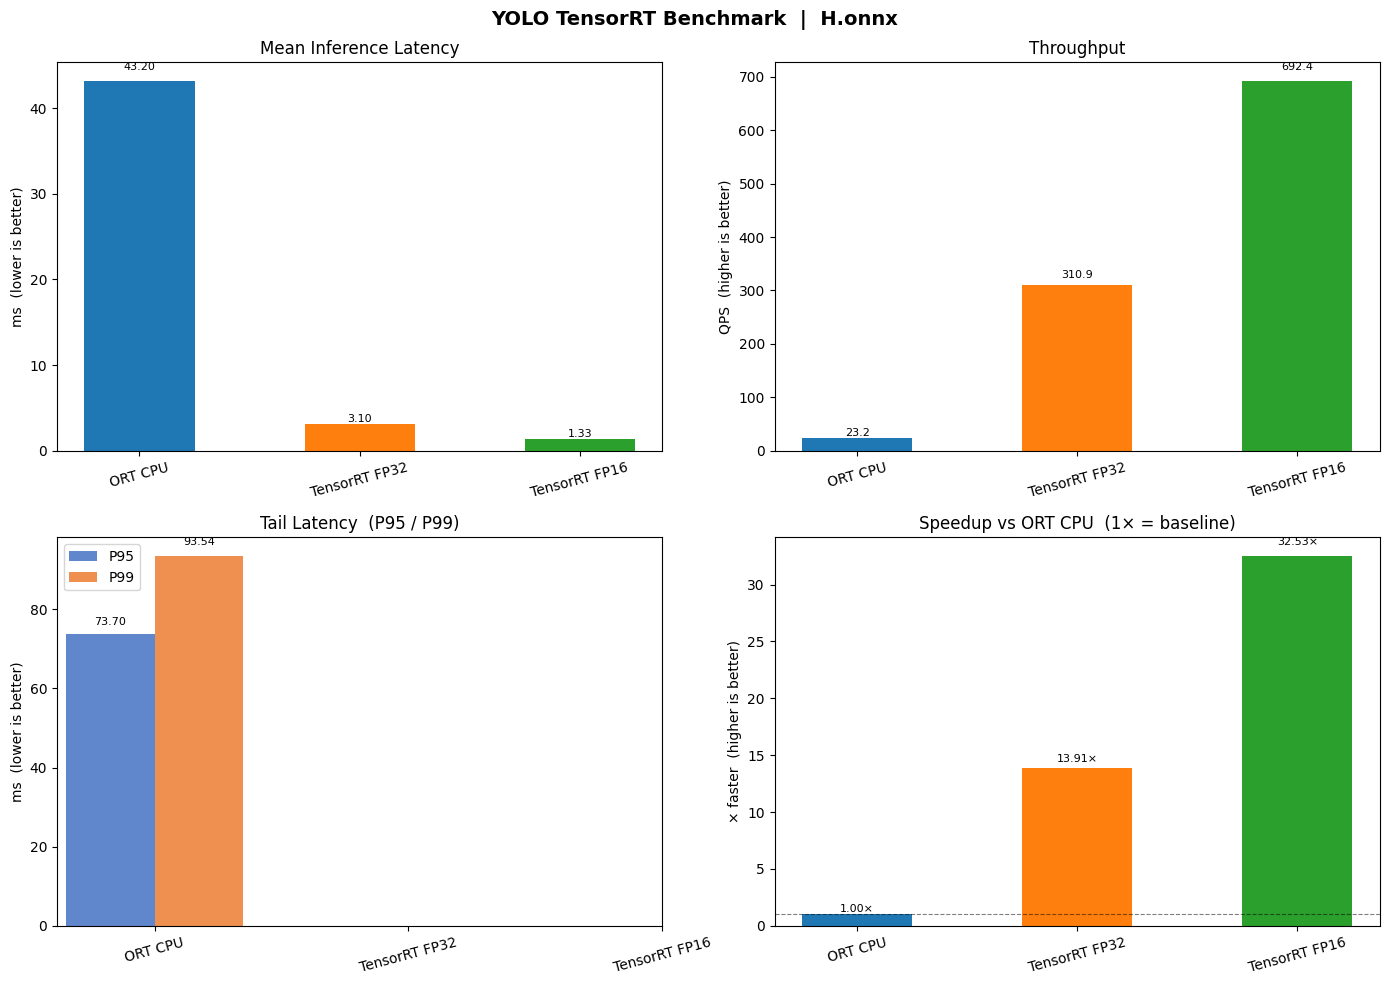

Saved → benchmark_results.png


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Build comparison rows — ORT TRT EP inserted only when available
ort_label = f"ORT {active_provider.replace('ExecutionProvider', '')}"
rows = [(ort_label, m_ort)]
if m_ort_trt_ep is not None:
    rows.append(("ORT TRT EP", m_ort_trt_ep))
rows += [
    ("TensorRT FP32", m_fp32),
    ("TensorRT FP16", m_fp16),
]

df = pd.DataFrame([
    {
        "Method":           label,
        "Mean (ms)":        m.get("mean_ms",        float("nan")),
        "Median (ms)":      m.get("median_ms",      float("nan")),
        "P95 (ms)":         m.get("p95_ms",         float("nan")),
        "P99 (ms)":         m.get("p99_ms",         float("nan")),
        "Throughput (QPS)": m.get("throughput_qps", float("nan")),
    }
    for label, m in rows
])

base_lat        = df.loc[0, "Mean (ms)"]
df["Speedup"]   = base_lat / df["Mean (ms)"]

print("=" * 86)
print(df.to_string(index=False, float_format="{:.3f}".format))
print("=" * 86)

# ── Helpers ───────────────────────────────────────────────────────────────────
n      = len(df)
colors = plt.cm.tab10.colors[:n]
labels = df["Method"].tolist()
x      = np.arange(n)
w      = 0.35

def annotate_bars(ax, bars, fmt="{:.2f}"):
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    h + abs(h) * 0.025,
                    fmt.format(h), ha="center", va="bottom", fontsize=8)

# ── 2×2 figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Mean latency
b1 = axes[0, 0].bar(labels, df["Mean (ms)"], color=colors, width=0.5)
axes[0, 0].set_title("Mean Inference Latency")
axes[0, 0].set_ylabel("ms  (lower is better)")
axes[0, 0].tick_params(axis="x", rotation=15)
annotate_bars(axes[0, 0], b1)

# 2. Throughput
b2 = axes[0, 1].bar(labels, df["Throughput (QPS)"], color=colors, width=0.5)
axes[0, 1].set_title("Throughput")
axes[0, 1].set_ylabel("QPS  (higher is better)")
axes[0, 1].tick_params(axis="x", rotation=15)
annotate_bars(axes[0, 1], b2, fmt="{:.1f}")

# 3. Tail latency grouped bar (P95 / P99)
bp95 = axes[1, 0].bar(x - w/2, df["P95 (ms)"], w, label="P95", color="#4472C4", alpha=0.85)
bp99 = axes[1, 0].bar(x + w/2, df["P99 (ms)"], w, label="P99", color="#ED7D31", alpha=0.85)
axes[1, 0].set_title("Tail Latency  (P95 / P99)")
axes[1, 0].set_ylabel("ms  (lower is better)")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(labels, rotation=15)
axes[1, 0].legend()
annotate_bars(axes[1, 0], list(bp95) + list(bp99))

# 4. Speedup vs baseline
b4 = axes[1, 1].bar(labels, df["Speedup"], color=colors, width=0.5)
axes[1, 1].axhline(1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
axes[1, 1].set_title(f"Speedup vs {labels[0]}  (1× = baseline)")
axes[1, 1].set_ylabel("× faster  (higher is better)")
axes[1, 1].tick_params(axis="x", rotation=15)
annotate_bars(axes[1, 1], b4, fmt="{:.2f}×")

plt.suptitle("YOLO TensorRT Benchmark  |  H.onnx", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("benchmark_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → benchmark_results.png")